In [8]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Loading the dataset from your local folder
df = pd.read_csv("C:\\Users\\Asus\\Desktop\\Week1_Internship\\students.csv")

print("Real Dataset Loaded Successfully from Local File!")
display(df.head())

Real Dataset Loaded Successfully from Local File!


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [10]:
# --- Cell 2: Exploratory Data Analysis (Stats) ---
print("--- 1. Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("--- 2. Dataset Description ---")
display(df.describe())

# Creating a Target Variable: 'Pass' (1) if average score >= 60, else 'Fail' (0)
df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3
df['target_pass'] = (df['average_score'] >= 60).astype(int)

print("\n--- 3. Class Distribution (Target Variable) ---")
print(df['target_pass'].value_counts())

--- 1. Dataset Shape ---
Rows: 1000, Columns: 8

--- 2. Dataset Description ---


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000



--- 3. Class Distribution (Target Variable) ---
target_pass
1    715
0    285
Name: count, dtype: int64


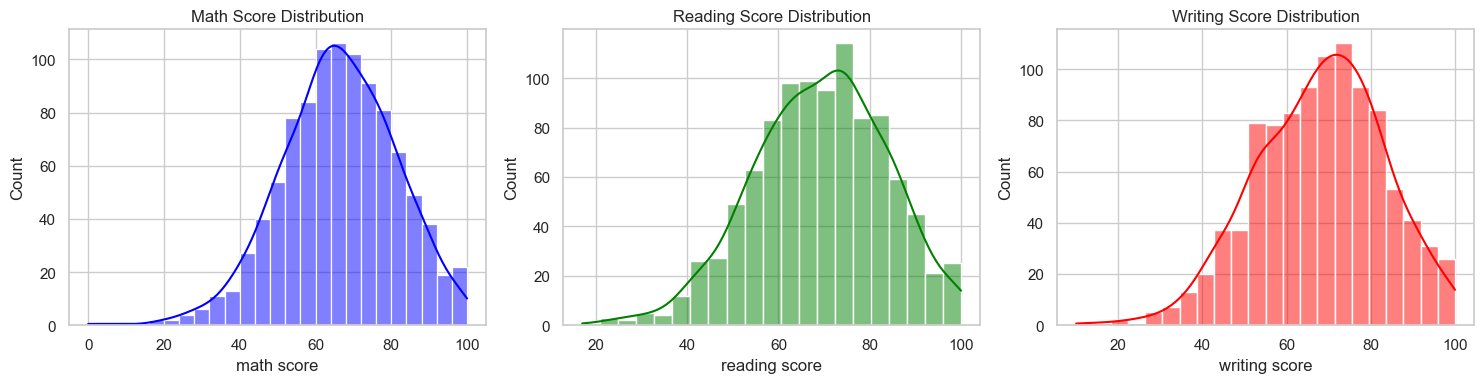

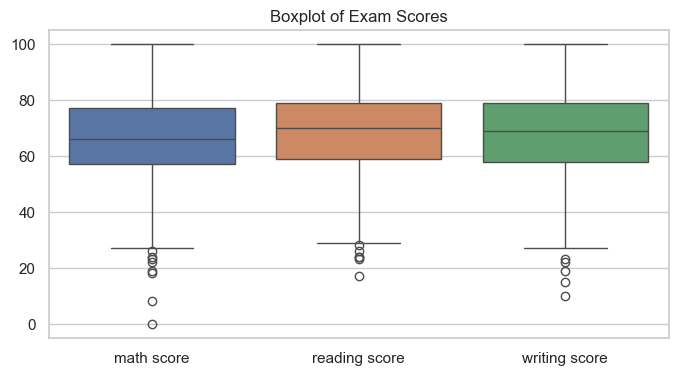

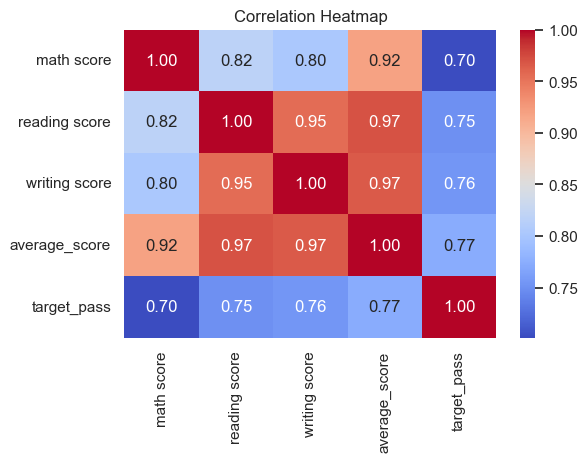

In [11]:
# --- Cell 3: Data Visualizations ---
# Set up the visualization style
sns.set_theme(style="whitegrid")

# 4. Histograms for Scores
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
sns.histplot(df['math score'], kde=True, color='blue')
plt.title('Math Score Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['reading score'], kde=True, color='green')
plt.title('Reading Score Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['writing score'], kde=True, color='red')
plt.title('Writing Score Distribution')
plt.tight_layout()
plt.show()

# 5. Box Plots for Outliers
plt.figure(figsize=(8, 4))
sns.boxplot(data=df[['math score', 'reading score', 'writing score']])
plt.title('Boxplot of Exam Scores')
plt.show()

# 6. Correlation Heatmap
plt.figure(figsize=(6, 4))
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [12]:
# --- Cell 4: Preprocessing & Data Splitting ---
# Drop original score columns to prevent data leakage (since they calculate the target)
X_raw = df.drop(['math score', 'reading score', 'writing score', 'average_score', 'target_pass'], axis=1)
y = df['target_pass']

# One-Hot Encode categorical variables (gender, race, parental education, lunch, test prep)
X = pd.get_dummies(X_raw, drop_first=True)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")

Training features shape: (800, 12)
Testing features shape: (200, 12)


========== Logistic Regression ==========
Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.24      0.32        62
           1       0.72      0.88      0.79       138

    accuracy                           0.68       200
   macro avg       0.59      0.56      0.55       200
weighted avg       0.64      0.68      0.64       200



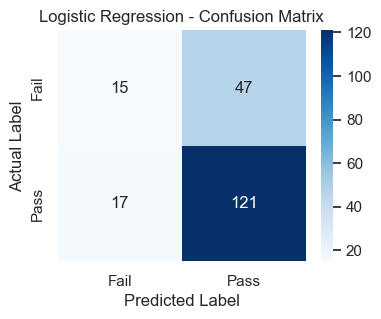



========== Random Forest ==========
Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.26      0.32        62
           1       0.72      0.84      0.77       138

    accuracy                           0.66       200
   macro avg       0.57      0.55      0.55       200
weighted avg       0.62      0.66      0.63       200



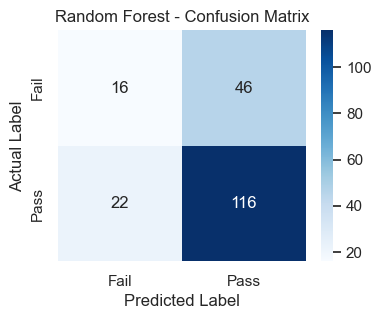

In [13]:
# --- Cell 5: Complete Model Evaluation ---
# Initialize Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Train and Evaluate Completely
for name, model in models.items():
    print(f"========== {name} ==========")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Complete Evaluation Metrics (Precision, Recall, F1-Score)
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix Visualization
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
    print("\n")